# Epälineaarisen luottotappioriskin mallintaminen regressiosplineillä

## Yhteenveto

Vähittäispankin riskitiimin on tiedettävä, *missä* maksuhäiriöriski muuttuu epälineaariseksi, ennen kuin se sitoutuu tuotantovaiheen pisteytysmalliin. Sen sijaan että jokainen muuttuja luokiteltaisiin ennalta käsin, tiimi sovittaa **yleistetyn additiivisen mallin** `PROC GAM` -proseduurilla: jokainen lainanottajan ominaisuus tulee malliin kuutiollisena tasoitussplinenä, joten kynnys- ja U-muotoiset yhteydet estimoidaan suoraan datasta logit-asteikolla. Tarkoituksellisen haastavassa synteettisessä 100 lainan salkussa (39 % maksuhäiriöisiä) additiivinen splinemalli pienentää devianssin arvosta 133,75 (pelkkä vakiotermi) arvoon 61,69 — pudotus 72,06 — mallin AIC-arvon ollessa 81,69. Velan ja tulojen suhteen (debt-to-income) sovitetulla splinellä on suurin kerroin (4,34), ja raakatuloksen luokittelu vahvistaa rakennetun rakenteen: maksuhäiriöriski on jyrkän **U-muotoinen iän suhteen** (66,7 % nuorimmilla lainanottajilla, 4,8 % keski-iässä, 86,4 % vanhimmilla) ja kasvaa velkaantumisen myötä.

## Datalähteet

| Aineisto | Rivejä | Rooli | Keskeiset muuttujat | Kuvaus |
|---------|------|------|---------------|-------------|
| `loans` | 100 | Mallinnussyöte | `default` (0/1 kohdemuuttuja), `age`, `dti` (velan ja tulojen suhde), `utilization` (uusiutuvan luoton käyttö) | Synteettiset vähittäislainojen hakemukset. Maksuhäiriön todellinen log-odds rakennetaan tarkoituksellisilla epälineaarisuuksilla — U-muotoinen ikävaikutus sekä kynnyskohdat velan ja tulojen suhteessa ja luoton käytössä — ja siitä otetaan Bernoulli-otos. Luotu suoraan koodissa komennoilla `call streaminit(20260531)` ja `rand()`; ei ulkoisia tiedostoja. |

Tämä ympäristö toimii ilman lisenssiä, joten tuloste on rajattu 100 havaintoon. Skenaario on mitoitettu tähän rajaan: signaali on tehty riittävän vahvaksi, jotta kolmitermin additiivinen splinemalli pystyy palauttamaan muodot 100 lainasta.

# Miksi splinet luottoriskiin

Perinteiset pisteytysmallit nojaavat logistiseen regressioon käsin luokitelluilla muuttujilla (weight-of-evidence / information-value). Se toimii, mutta pakottaa analyytikon *arvaamaan*, missä riskikynnykset ja kaarevuus sijaitsevat. **Yleistetty additiivinen malli (GAM)** korvaa jokaisen lineaarisen termin sileällä funktiolla — tässä kuutiollisella tasoitusplinellä, jolla on kolme vapausastetta — joten käyrän muoto estimoidaan sen sijaan että se oletettaisiin. `PROC GAM` sovittaa nämä sileät funktiot logit-asteikolla binääriselle kohdemuuttujalle, juuri siihen asetelmaan, jossa maksuhäiriön todennäköisyyttä mallinnetaan.

Tässä muistikirjassa esitämme vähittäispankin riskitiimin roolia. Me:

1. Luomme synteettisen lainasalkun, jonka **todellinen** maksuhäiriötodennäköisyys on aidosti epälineaarinen (U-muotoinen ikävaikutus sekä kynnysvaikutukset velan ja tulojen suhteessa ja luoton käytössä).
2. Sovitamme binomi-/logit-additiivisen splinemallin ja luemme sen devianssin, AIC:n sekä splinekohtaiset kertoimet.
3. Vahvistamme palautetut muodot luokittelemalla raa'an maksuhäiriötuloksen ja piirtämällä sen `PROC SGPLOT` -proseduurilla.

Mikään tässä ei vaadi ulkoista dataa tai verkkoyhteyttä.

## Vaihe 1 - Rakenna synteettinen lainasalkku

Simuloimme 100 lainahakemusta. Jokaisella lainanottajalla on kolme ominaisuutta. Maksuhäiriön **log-odds** rakennetaan tarkoituksellisen epälineaarisista komponenteista, jotta meillä on tunnettu perustotuus, jonka splinemalli voi palauttaa:

- **Ikä** - U-muoto: maksuhäiriöriski on koholla hyvin nuorilla ja hyvin vanhoilla lainanottajilla ja matalimmillaan keski-iässä. Koodaamme tämän neliöitynä, keskitettynä ikätermínä.
- **DTI** - kynnysvaikutus: vähäinen vaikutus, kunnes velan ja tulojen suhde ylittää noin 0,35, minkä jälkeen riski kasvaa (yksipuolinen taitekohta).
- **Luoton käyttö** - toinen taitekohta noin 0,60:ssa uusiutuvasta luottolimiitistä.

Binäärinen `default`-lippu arvotaan sitten Bernoulli-jakaumasta tuolla todennäköisyydellä. Vakiotermi asetetaan riittävän matalaksi, jotta rakennetut epälineaarisuudet — eivät korkea perustaso — ohjaavat maksuhäiriöitä. Tämä on tarkoituksellisen haastava, korkean riskin salkku, joka on valittu niin, että muodot ovat näkyvissä jo 100 lainassa.

In [1]:
TIEDOT loans;
   CALL streaminit(20260531);

   TEE id = 1 ASTI 100;
      /* ---- lainanottajan ominaisuudet ---- */
      age         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 vuotta   */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* velan ja tulojen suhde */
      utilization = rand("UNIFORM");               /* 0 .. 1 rajasta    */

      /* ---- TODELLINEN epälineaarinen maksuhäiriön log-odds ---- */
      age_c    = (age - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* U-muotoinen       */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* kynnyskohta       */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* kynnyskohta       */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIC(eta);
      default = rand("BERNOULLI", p_true);

      POISTA age_c eta_age eta_dti eta_util eta p_true;
      TULOSTE;
   LOPPU;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=loans n mean MIN MAX maxdec=3;
   MUUTTUJA default age dti utilization;
   NIMIKE default="Maksuhäiriö" age="Ikä" dti="Velan ja tulojen suhde"
         utilization="Luoton käyttöaste";
SUORITA;

                                                  The MEANS Procedure

 Variable     Label                          N           Mean     Minimum     Maximum
 ------------------------------------------------------------------------------------
 default      Maksuhäiriö                  100          0.390       0.000       1.000
 age          Ikä                          100         44.993      18.342      69.646
 dti          Velan ja tulojen suhde       100          0.312       0.059       0.590
 utilization  Luoton käyttöaste            100          0.548       0.012       0.988
 ------------------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


`PROC MEANS` -yhteenveto vahvistaa salkun: kokonaismaksuhäiriöaste on **39 %** (stressattu, korkean riskin kirja), ikä vaihtelee välillä 18-70, velan ja tulojen suhde on keskimäärin 0,31 ja luoton käyttö keskimäärin 0,55 koko välillä 0-1. Kun data on käsillä, voimme sovittaa mallin.

## Vaihe 2 - Sovita additiivinen splinemalli

`MODEL`-lause nimeää binäärisen vasteen ja kietoo jokaisen selittäjän muotoon `spline(var, df=3)`, mikä pyytää kuutiollista tasoitusplineä, jolla on kolme vapausastetta kullekin. Asetukset:

- `event='1'` - mallinnetaan *maksuhäiriö*tapahtuman todennäköisyyttä, ei ei-tapahtumaa.
- `dist=binomial` - 0/1-kohdemuuttuja sovitettuna logit-asteikolla, luonteva valinta maksuhäiriötodennäköisyydelle.

`PROC GAM` raportoi mallin **devianssin** ja **AIC:n**, kertoimen jokaiselle sileälle termille sekä tasoitusmallitaulukon, joka luettelee kutakin komponenttia kohti käytetyt vapausasteet.

In [2]:
OTSIKKO "Lainan maksuhäiriön yleistetty additiivinen logistinen malli";

PROSEDUURI gam TIEDOT=loans;
   MODEL default(EVENT="1") = SPLINE(age,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
   NIMIKE default="Maksuhäiriö" age="Ikä"
         dti="Velan ja tulojen suhde" utilization="Luoton käyttöaste";
SUORITA;

OTSIKKO;

                              Lainan maksuhäiriön yleistetty additiivinen logistinen malli                              


                                                   The GAM Procedure                                                    

Model Information
Response Variable     Maksuhäiriö
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spl


NOTE: Option TITLE changed to Lainan maksuhäiriön yleistetty additiivinen logistinen malli.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


Sovitus on vahva. **Nolladevianssi** 133,75 (pelkkä vakiotermimalli) putoaa jäännösdevianssiin **61,69**, kun kolme sileää termiä lisätään — vähennys 72,06 — ja mallin **AIC on 81,69**. Sileistä termeistä **velan ja tulojen suhteen splinellä on suurin kerroin (4,34)**, iän ja luoton käytön splinien edellä, mikä osoittaa velkaantumisen sovitetun log-oddsin hallitsevaksi ajuriksi. Kukin sileä termi käyttää kolme vapausastetta, kuten pyydettiin. Malli on löytänyt, että nämä yhteydet ovat epälineaarisia ilman että olisimme määrittäneet ainuttakaan luokkaa tai polynomitermiä.

## Vaihe 3 - Vahvista palautetut muodot

Sovitettu sileä funktio on vakuuttava vain, jos se vastaa raakadataa. Luokittelemme jokaisen lainanottajan iän ja velan ja tulojen suhteen mukaan, laskemme toteutuneen maksuhäiriöasteen kussakin kaistassa `PROC MEANS` -proseduurilla ja piirrämme sen `PROC SGPLOT` -proseduurilla. Jos splinemalli kertoo totuuden, luokitellun tuloksen tulisi seurata samaa U-muotoa ja kynnystä, jotka malli sovitti.

In [3]:
TIEDOT binned;
   ASETA loans;
   PITUUS dti_band $9 age_band $5;

   JOS      dti < 0.20 NIIN dti_band = "0.00-0.20";
   MUUTEN JOS dti < 0.30 NIIN dti_band = "0.20-0.30";
   MUUTEN JOS dti < 0.40 NIIN dti_band = "0.30-0.40";
   MUUTEN JOS dti < 0.50 NIIN dti_band = "0.40-0.50";
   MUUTEN                    dti_band = "0.50+";

   JOS      age < 30 NIIN age_band = "18-30";
   MUUTEN JOS age < 40 NIIN age_band = "30-40";
   MUUTEN JOS age < 50 NIIN age_band = "40-50";
   MUUTEN JOS age < 60 NIIN age_band = "50-60";
   MUUTEN                  age_band = "60-70";
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=binned NWAY NOPRINT;
   LUOKKA age_band;
   MUUTTUJA default;
   TULOSTE out=age_rate(POISTA=_type_ _freq_)
          n=n mean(default)=def_rate;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=binned NWAY NOPRINT;
   LUOKKA dti_band;
   MUUTTUJA default;
   TULOSTE out=dti_rate(POISTA=_type_ _freq_)
          n=n mean(default)=def_rate;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=age_rate noobs NIMIKE;
   MUUTTUJA age_band n def_rate;
   NIMIKE age_band="Ikäluokka" n="Tilejä" def_rate="Maksuhäiriöaste";
   MUOTO def_rate percent8.1;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=dti_rate noobs NIMIKE;
   MUUTTUJA dti_band n def_rate;
   NIMIKE dti_band="Velan ja tulojen suhde -luokka" n="Tilejä"
         def_rate="Maksuhäiriöaste";
   MUOTO def_rate percent8.1;
SUORITA;


 Ikäluokka   Tilejä    Maksuhäiriöaste
----------  -------  -----------------
18-30            21              66.7%
30-40            19              10.5%
40-50            21               4.8%
50-60            17              17.6%
60-70            22              86.4%

Velan ja tulojen suhde -luokka   Tilejä    Maksuhäiriöaste
------------------------------  -------  -----------------
0.00-0.20                            29              37.9%
0.20-0.30                            21              28.6%
0.30-0.40                            15              33.3%
0.40-0.50                            20              50.0%
0.50+                                15              46.7%




NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


Ikäkaistat piirtävät selkeän U:n: **66,7 %** alle 30-vuotiaista lainanottajista joutui maksuhäiriöön, aste saavuttaa pohjansa **4,8 %:ssa** kaistalla 40-50, ja nousee sitten takaisin **86,4 %:iin** 60-vuotiailla ja sitä vanhemmilla. Velan ja tulojen suhteen kaistat kohoavat kokonaisuudessaan — matalimman kaistan yli 30 prosentista noin 50 prosenttiin DTI-arvon 0,40 jälkeen — vaikka vain 100 lainalla kaistakohtaiset asteet ovat kohinaisia, mikä on juuri se syy, miksi mallin sileä funktio (yksittäisen kovan raja-arvon sijaan) on luotettavampi yhteenveto. Alla olevat kuvaajat tekevät molemmat muodot näkyviksi.

### Ikävaikutus on U-muotoinen

Toteutuneen maksuhäiriöasteen piirtäminen ikäkaistoittain paljastaa kaarevuuden, jonka spline palautti: korkea riski ikäjakauman molemmissa päissä, syvä aallonpohja keski-iässä.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


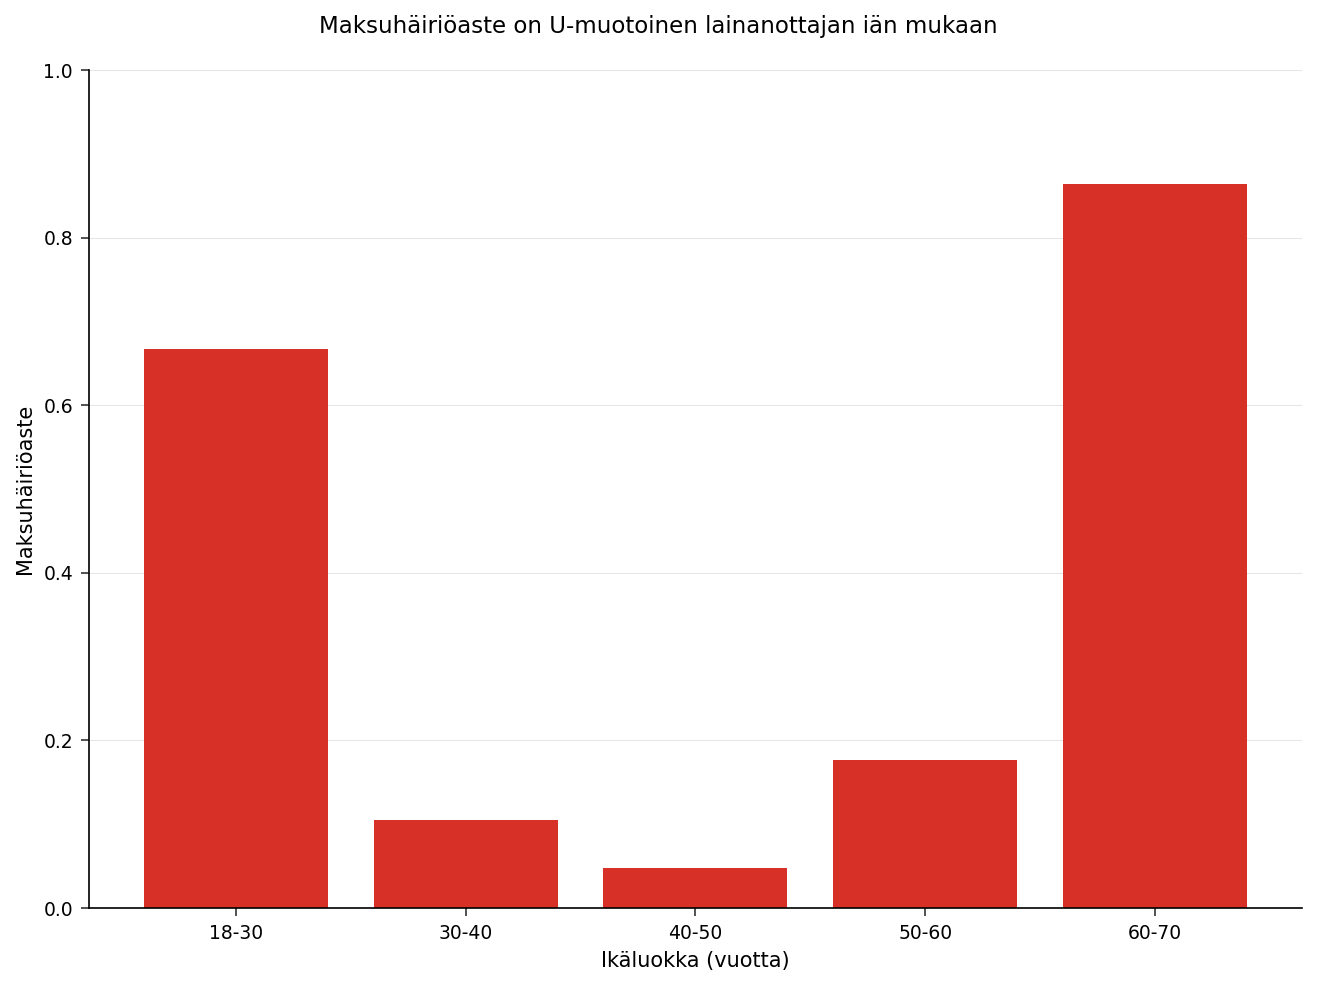

In [4]:
ODS GRAPHICS ON;

PROSEDUURI SGPLOT TIEDOT=age_rate noautolegend;
   OTSIKKO "Maksuhäiriöaste on U-muotoinen lainanottajan iän mukaan";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS NIMIKE="Maksuhäiriöaste" VALUES=(0 ASTI 1 MUKAAN 0.2) grid;
   XAXIS NIMIKE="Ikäluokka (vuotta)";
SUORITA;

OTSIKKO;
ODS GRAPHICS OFF;

### Riski kasvaa velkaantumisen myötä

Velan ja tulojen suhteen kaistat trendaavat ylöspäin — velkaantuneimmat lainanottajat joutuvat maksuhäiriöön useimmin — yhdenmukaisesti mallin hallitsevan DTI-splinen kanssa. Keskikaistat ovat kohinaisia tällä otoskoolla, mikä korostaa, miksi sovitettu spline on vakaampi opas kuin mikään yksittäinen käsin piirretty raja-arvo.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


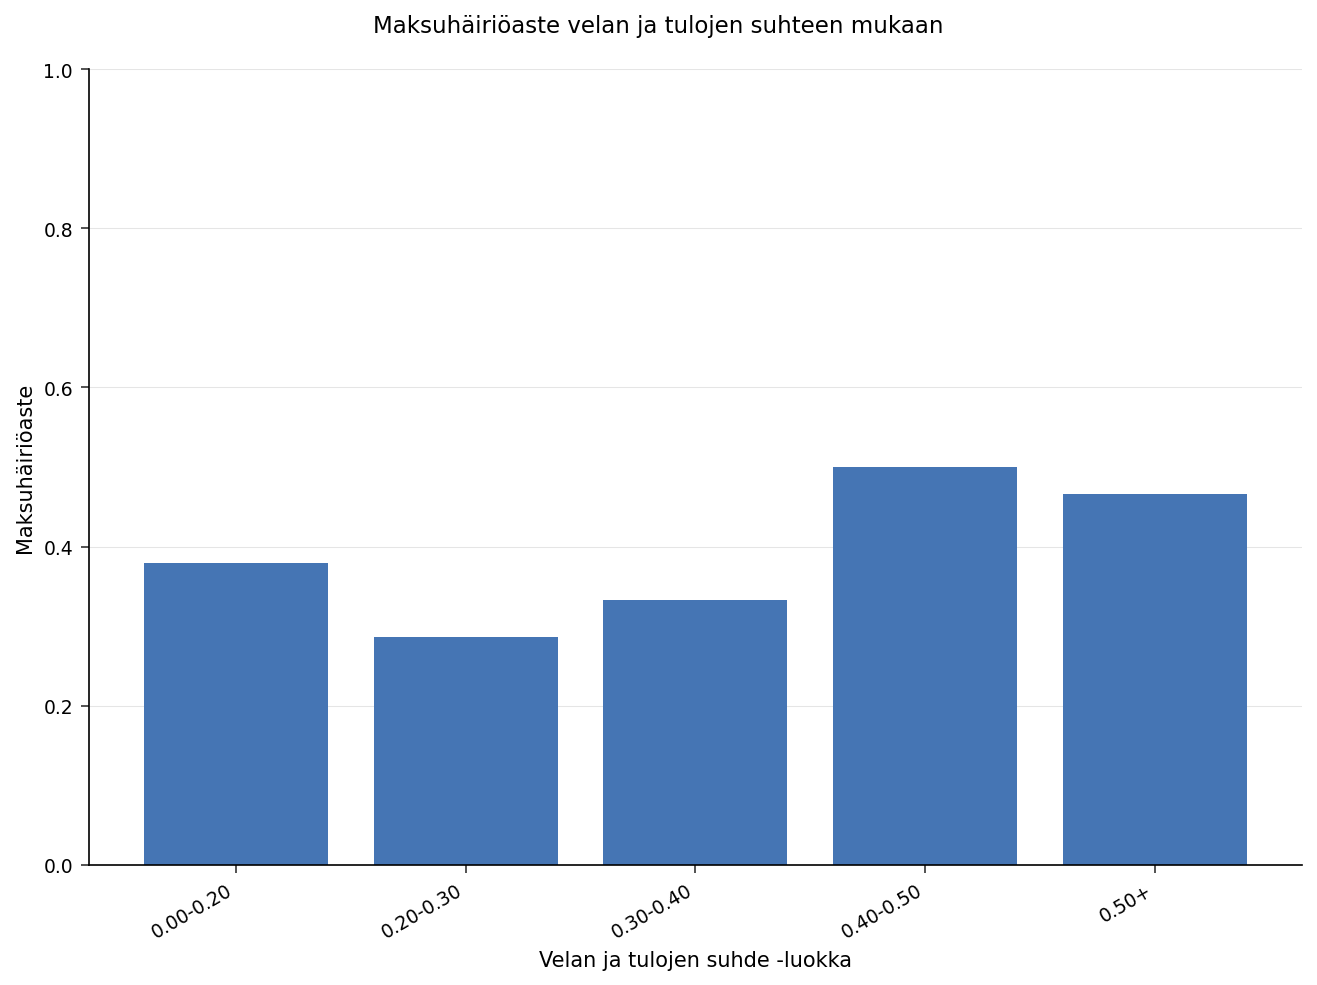

In [5]:
ODS GRAPHICS ON;

PROSEDUURI SGPLOT TIEDOT=dti_rate noautolegend;
   OTSIKKO "Maksuhäiriöaste velan ja tulojen suhteen mukaan";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS NIMIKE="Maksuhäiriöaste" VALUES=(0 ASTI 1 MUKAAN 0.2) grid;
   XAXIS NIMIKE="Velan ja tulojen suhde -luokka";
SUORITA;

OTSIKKO;
ODS GRAPHICS OFF;

## Tulosten tulkinta

`PROC GAM` palautti epälineaarisen rakenteen, jonka rakensimme synteettiseen salkkuun, ilman minkäänlaista käsin tehtyä luokittelua tai polynomitermejä:

- **Vahva kokonaissovitus** - additiivinen splinemalli painaa devianssin arvosta 133,75 alas arvoon 61,69 (vähennys 72,06) mallin AIC-arvon ollessa 81,69, kirjalla jonka perusmaksuhäiriöaste on 39 %.
- **Velkaantuminen hallitsee** - velan ja tulojen suhteen splinellä on kolmen termin suurin kerroin (4,34), mikä nostaa DTI:n sovitetun log-oddsin johtavaksi ajuriksi.
- **Kaarevuus iässä** - raakatuloksen luokittelu vahvistaa oppikirjamaisen U:n: 66,7 % maksuhäiriöitä alle 30-vuotiaiden kaistalla, 4,8 %:n aallonpohja välillä 40-50 ja 86,4 % 60-vuotiaiden ja vanhempien kaistalla — muoto, jonka kuutiollinen spline vangitsee luontevasti mutta jonka yksittäinen lineaarinen ikätermi ohittaisi kokonaan.
- **Rehellinen kohinasta** - 100 lainalla kaistakohtaiset velan ja tulojen suhteen asteet heiluvat, mikä on juuri se tapaus, jossa sileä estimaatti voittaa kovan käsin valitun raja-arvon.

**Miksi tällä on merkitystä pankkitoiminnalle:** additiiviset splinet antavat riskitiimille nopean, automaattisen tavan havaita, missä yhteys on aidosti epälineaarinen, ennen tuotantovaiheen pisteytysmalliin sitoutumista. Sovitetut sileät funktiot ovat suoraan tulkittavissa riskikäyrinä — nuorten ja vanhojen ikäpreemio, velkaantumisen ramppi — ja devianssi sekä AIC kvantifioivat, kuinka paljon tuo joustavuus tuo verrattuna tasaiseen lineaariseen malliin.